In [1]:
# --------------------
# PART 0: Imports
# --------------------
from google.colab import drive
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.utils import shuffle

In [2]:
# ------------------------------------------
# PART 1: Mount Drive & Set Correct Paths
# ------------------------------------------
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/ML_Project/Rock_Paper_Scissors/Rock-Paper-Scissors'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

categories = ['rock', 'paper', 'scissors']
IMG_SIZE = 48

Mounted at /content/drive


In [3]:
# ------------------------------------
# PART 2: Load Dataset & Shuffle
# ------------------------------------
def load_data(directory):
    """Load images and labels from a given directory with early resizing and shuffling."""
    X, y = [], []
    for category in categories:
        folder_path = os.path.join(directory, category)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder not found -> {folder_path}")
            continue

        label = categories.index(category)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                # Convert to RGB for proper plotting and resize early to save RAM
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, (150, 150))
                X.append(img_resized)
                y.append(label)

    # Shuffle indices to prevent sequence bias and maintain exact mapping
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    return np.array([X[i] for i in indices]), np.array([y[i] for i in indices])

print("Loading Train and Test datasets separately...")
X_train_raw, y_train = load_data(train_dir)
X_test_raw, y_test = load_data(test_dir)
print(f"Loaded {len(X_train_raw)} Train images and {len(X_test_raw)} Test images.")

Loading Train and Test datasets separately...
Loaded 2520 Train images and 372 Test images.



--- Feature Engineering (Smart Square Crop) ---


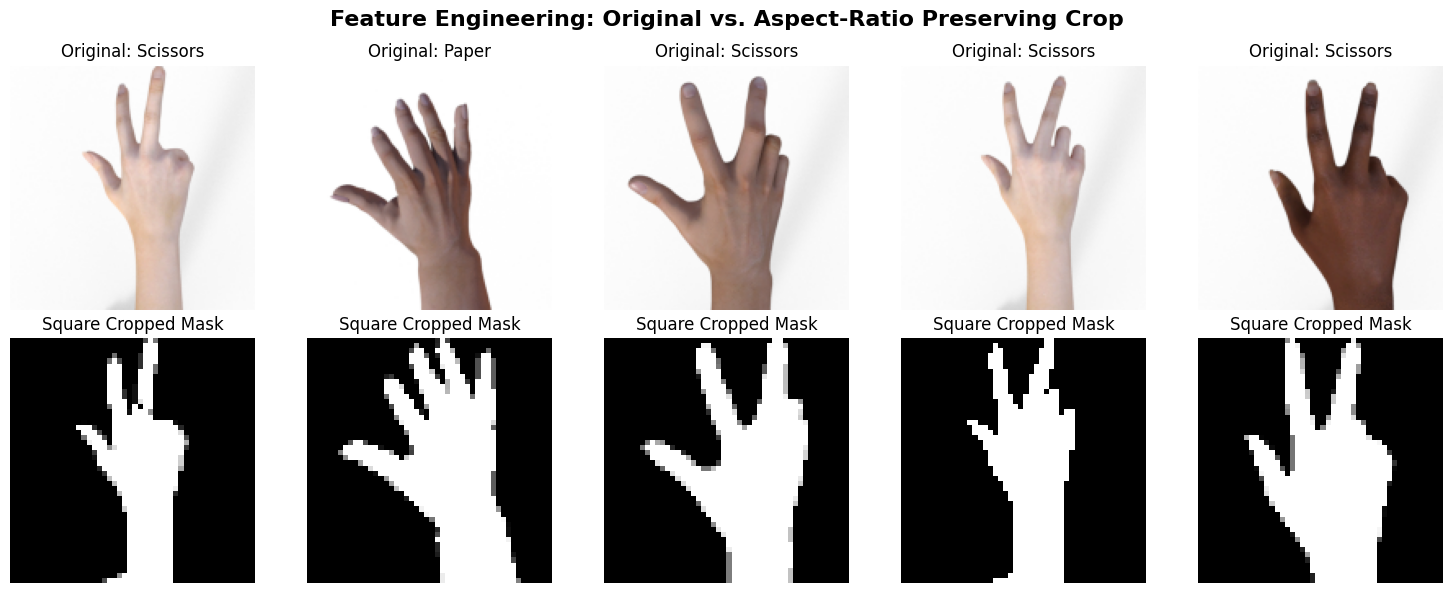

In [4]:
# ------------------------------------------------------------------------
# PART 3: Feature Engineering (Aspect-Ratio Preserving Crop)
# ------------------------------------------------------------------------
def get_hand_mask_and_crop(img_rgb):
    """
    Applies Grayscale -> Gaussian Blur -> Otsu Thresholding -> Aspect-Ratio Preserving Crop.
    Padding the cropped bounding box to a perfect square before resizing prevents
    shape distortion (e.g., stopping 'Paper' from squashing and looking like 'Rock').
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu thresholding separates the hand from the white background
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find bounding box to crop out empty background
    points = cv2.findNonZero(thresh)
    if points is not None:
        x, y, w, h = cv2.boundingRect(points)
        cropped_hand = thresh[y:y+h, x:x+w]

        # Pad the image to a square BEFORE resizing to preserve aspect ratio
        max_dim = max(w, h)
        pad_top = (max_dim - h) // 2
        pad_bottom = max_dim - h - pad_top
        pad_left = (max_dim - w) // 2
        pad_right = max_dim - w - pad_left

        # Add black padding (value=0) around the hand
        square_hand = cv2.copyMakeBorder(cropped_hand, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_CONSTANT, value=0)
    else:
        square_hand = thresh

    # Resize to the final grid
    resized = cv2.resize(square_hand, (IMG_SIZE, IMG_SIZE))
    return resized

print("\n--- Feature Engineering (Smart Square Crop) ---")
X_train_masks = np.array([get_hand_mask_and_crop(img) for img in X_train_raw])
X_test_masks = np.array([get_hand_mask_and_crop(img) for img in X_test_raw])

# Visualizing the Feature Engineering Process
num_examples = 5
fig, axes = plt.subplots(2, num_examples, figsize=(15, 6))

for i in range(num_examples):
    # Top row: Original images
    axes[0, i].imshow(X_train_raw[i])
    axes[0, i].set_title(f"Original: {categories[y_train[i]].capitalize()}")
    axes[0, i].axis('off')

    # Bottom row: Processed masks
    axes[1, i].imshow(X_train_masks[i], cmap='gray')
    axes[1, i].set_title("Square Cropped Mask")
    axes[1, i].axis('off')

plt.suptitle("Feature Engineering: Original vs. Aspect-Ratio Preserving Crop", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Flatten and Normalize for the Algorithm
X_train_features = X_train_masks.reshape(len(X_train_masks), -1)
X_test_features = X_test_masks.reshape(len(X_test_masks), -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

In [5]:
# ------------------------------------------------------------
# PART 4: Algorithm Implementation, Grid Search & Training
# ------------------------------------------------------------
print("\n--- Hyperparameter Tuning (Grid Search & 5-Fold CV) ---")

# Define the hyperparameter grid to search (Cartesian product)
param_grid = {
    'n_neighbors': [5, 11, 15, 19, 25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

# Configure 5-Fold Cross Validation
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV using Macro F1-Score as the scoring metric
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1
)

# Execute Grid Search
print("Running Grid Search... This might take a minute.")
grid_search.fit(X_train_scaled, y_train)

# Presenting Results in a DataFrame (Bonus Requirement)
results_df = pd.DataFrame(grid_search.cv_results_)
display_cols = ['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score']
results_df = results_df[display_cols].sort_values(by='mean_test_score', ascending=False)
results_df.columns = ['K (Neighbors)', 'Weights', 'Distance Metric', 'Mean CV Macro F1']

print("\n>>> Top 5 Hyperparameter Permutations (Cross-Validation Results DataFrame):")
print("==========================================================================")
print(results_df.head(5).to_string(index=False))
print("==========================================================================")

print(f"\n>>> BEST PERMUTATION FOUND:")
print(f"Parameters: {grid_search.best_params_}")
print(f"Best Macro Average F1-Score (Cross-Validation): {grid_search.best_score_:.4f}")

# Extract the best model (GridSearchCV automatically refits it on the full trainset)
best_knn_model = grid_search.best_estimator_
print("\nTraining final model on the entire trainset using the best parameters... Completed.")


--- Hyperparameter Tuning (Grid Search & 5-Fold CV) ---
Running Grid Search... This might take a minute.

>>> Top 5 Hyperparameter Permutations (Cross-Validation Results DataFrame):
 K (Neighbors)  Weights Distance Metric  Mean CV Macro F1
             5 distance       euclidean          1.000000
             5 distance       manhattan          1.000000
             5  uniform       manhattan          0.999187
             5  uniform       euclidean          0.999187
            11 distance       manhattan          0.997233

>>> BEST PERMUTATION FOUND:
Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Best Macro Average F1-Score (Cross-Validation): 1.0000

Training final model on the entire trainset using the best parameters... Completed.



--- Prediction and Model Quality Evaluation ---


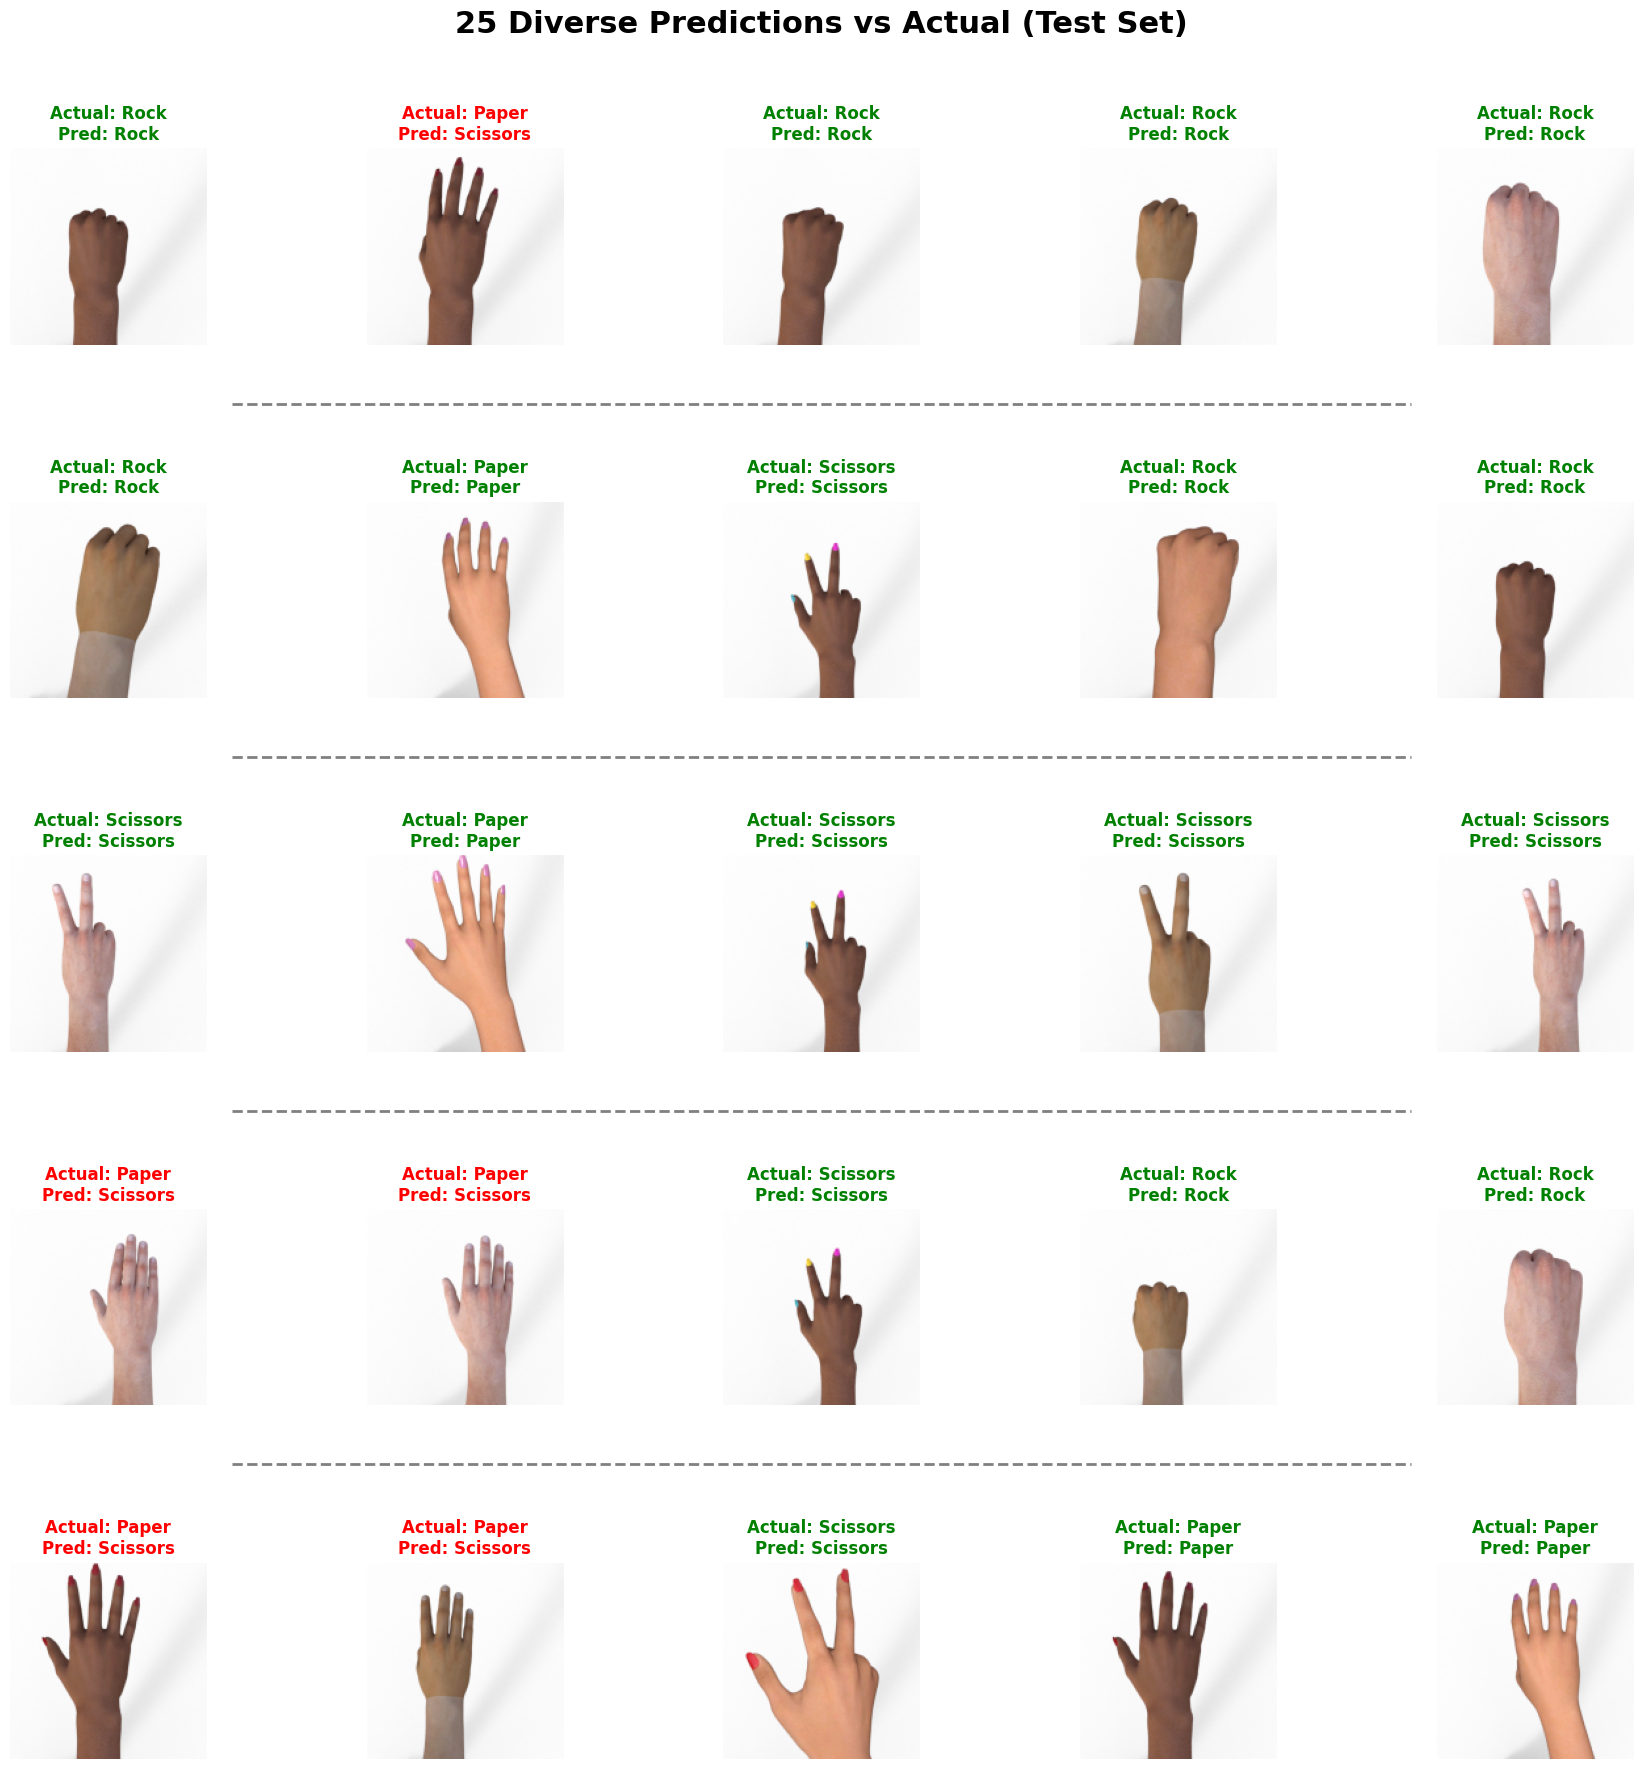


Final Model Quality on Test Set (Macro Average F1-Score): 0.7734


In [6]:
# --------------------------------------------------
# PART 5: Prediction and Evaluation on Test Set
# --------------------------------------------------
print("\n--- Prediction and Model Quality Evaluation ---")

if len(X_test_scaled) > 0:
    # Predict using the BEST model found by Grid-Search
    y_pred = best_knn_model.predict(X_test_scaled)

    # Classification Visualization: 5 Rows x 5 Columns (25 Images)
    rows, cols = 5, 5
    fig, axes = plt.subplots(rows, cols, figsize=(18, 18))

    for row_idx in range(rows):
        for col_idx in range(cols):
            img_idx = row_idx * cols + col_idx

            if img_idx < len(X_test_raw):
                ax = axes[row_idx, col_idx]
                ax.imshow(X_test_raw[img_idx])

                actual_label = categories[y_test[img_idx]].capitalize()
                pred_label = categories[y_pred[img_idx]].capitalize()

                text_color = 'green' if y_test[img_idx] == y_pred[img_idx] else 'red'
                title_text = f"Actual: {actual_label}\nPred: {pred_label}"

                ax.set_title(title_text, color=text_color, fontweight='bold', fontsize=12)
                ax.axis('off')

        # Add a dashed line separator between rows
        if row_idx < rows - 1:
            ax_mid = axes[row_idx, 2]
            ax_mid.plot([-2.5, 3.5], [-0.3, -0.3], color='gray', linestyle='--', linewidth=2, transform=ax_mid.transAxes, clip_on=False)

    plt.suptitle("25 Diverse Predictions vs Actual (Test Set)", fontsize=22, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.subplots_adjust(hspace=0.8)
    plt.show()

    # Calculate Final Macro Average F1-Score
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"\n===================================================")
    print(f"Final Model Quality on Test Set (Macro Average F1-Score): {macro_f1:.4f}")
    print(f"===================================================")
else:
    print("Test set is empty. Cannot perform evaluation.")